# Notebook 12 — Tối ưu Mô hình (Model Optimization)

Notebook này thử nghiệm các siêu tham số (hyperparameters) khác nhau cho mô hình GraphSAGE (như kích thước hidden layer và learning rate) để tìm ra cấu hình tốt nhất. Chúng ta sẽ lưu lại kết quả AUC trên tập Validation để so sánh.

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.nn import SAGEConv, HeteroConv
from torch_geometric.data import HeteroData
from torch_geometric.loader import LinkNeighborLoader
import torch_geometric.transforms as T
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm
from pathlib import Path

sns.set_theme(style="whitegrid")

## 1. Định nghĩa Kiến trúc GraphSAGE

In [2]:
class HeteroSAGEEncoder(nn.Module):
    def __init__(self, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = HeteroConv({
            ('user', 'reviews', 'item'):      SAGEConv((-1, -1), hidden_channels),
            ('item', 'rev_reviews', 'user'):  SAGEConv((-1, -1), hidden_channels),
            ('item', 'also_bought', 'item'):  SAGEConv((-1, -1), hidden_channels),
        }, aggr='sum')

        self.conv2 = HeteroConv({
            ('user', 'reviews', 'item'):      SAGEConv((-1, -1), out_channels),
            ('item', 'rev_reviews', 'user'):  SAGEConv((-1, -1), out_channels),
            ('item', 'also_bought', 'item'):  SAGEConv((-1, -1), out_channels),
        }, aggr='sum')

    def forward(self, x_dict, edge_index_dict):
        x_dict = self.conv1(x_dict, edge_index_dict)
        x_dict = {key: x.relu() for key, x in x_dict.items()}
        x_dict = self.conv2(x_dict, edge_index_dict)
        return x_dict

class DotProductDecoder(nn.Module):
    def forward(self, user_emb, item_emb):
        return (user_emb * item_emb).sum(dim=-1)

class GraphSAGELinkPredictor(nn.Module):
    def __init__(self, hidden_channels=64, out_channels=64):
        super().__init__()
        self.encoder = HeteroSAGEEncoder(hidden_channels, out_channels)
        self.decoder = DotProductDecoder()

    def encode(self, x_dict, edge_index_dict):
        return self.encoder(x_dict, edge_index_dict)

    def decode(self, user_emb, item_emb):
        return self.decoder(user_emb, item_emb)

## 2. Load Data và Chuẩn bị Train/Val Split
Sử dụng `RandomLinkSplit` để tách cạnh cho việc huấn luyện.

In [3]:
data_path = Path("../data/processed/hetero_data.pt")
data = torch.load(data_path, weights_only=False)
data = T.ToUndirected()(data)

# Split data (80/10/10)
split_transform = T.RandomLinkSplit(
    num_val=0.1,
    num_test=0.1,
    disjoint_train_ratio=0.3,
    edge_types=[('user', 'reviews', 'item')],
    rev_edge_types=[('item', 'rev_reviews', 'user')],
    add_negative_train_samples=False
)
train_data, val_data, test_data = split_transform(data)
print("Dữ liệu đã được chia Train / Val / Test")

Dữ liệu đã được chia Train / Val / Test


## 3. Hàm Huấn Luyện (Training Loop)
Viết một hàm để khởi tạo, huấn luyện mô hình trong vài epoch và trả về điểm AUC trên tập Validation.

In [4]:
def train_and_evaluate(hidden_channels, lr, epochs=3, batch_size=1024):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    model = GraphSAGELinkPredictor(hidden_channels, hidden_channels).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    # Loaders
    train_loader = LinkNeighborLoader(
        data=train_data,
        num_neighbors=[10, 10],
        neg_sampling_ratio=1.0,
        edge_label_index=(('user', 'reviews', 'item'), train_data['user', 'reviews', 'item'].edge_label_index),
        edge_label=train_data['user', 'reviews', 'item'].edge_label,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0
    )
    
    val_loader = LinkNeighborLoader(
        data=val_data,
        num_neighbors=[10, 10],
        edge_label_index=(('user', 'reviews', 'item'), val_data['user', 'reviews', 'item'].edge_label_index),
        edge_label=val_data['user', 'reviews', 'item'].edge_label,
        batch_size=batch_size,
        num_workers=0
    )
    
    loss_fn = torch.nn.BCEWithLogitsLoss()
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        # Train loop
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            
            z_dict = model.encode(batch.x_dict, batch.edge_index_dict)
            edge_label_index = batch['user', 'reviews', 'item'].edge_label_index
            out = model.decode(z_dict['user'][edge_label_index[0]], z_dict['item'][edge_label_index[1]])
            
            loss = loss_fn(out, batch['user', 'reviews', 'item'].edge_label)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            
    # Eval loop
    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            z_dict = model.encode(batch.x_dict, batch.edge_index_dict)
            edge_label_index = batch['user', 'reviews', 'item'].edge_label_index
            out = model.decode(z_dict['user'][edge_label_index[0]], z_dict['item'][edge_label_index[1]])
            
            preds.append(out.cpu())
            targets.append(batch['user', 'reviews', 'item'].edge_label.cpu())
            
    preds = torch.cat(preds, dim=0).numpy()
    targets = torch.cat(targets, dim=0).numpy()
    val_auc = roc_auc_score(targets, preds)
    
    return val_auc

## 4. Chạy Grid Search Tối Ưu Hóa
Thử nghiệm 3 cấu hình siêu tham số (Cấu hình nhỏ, vừa, và lớn).

In [5]:
import warnings
warnings.filterwarnings('ignore')

configs = [
    {'hidden_channels': 64, 'lr': 0.01, 'name': 'Baseline (LR cao)'},
    {'hidden_channels': 128, 'lr': 0.005, 'name': 'Wider (Cân bằng)'},
    {'hidden_channels': 256, 'lr': 0.001, 'name': 'Deep (LR thấp)'}
]

results = []
print("Đang tiến hành tối ưu hóa mô hình...")
for cfg in configs:
    print(f"Thử nghiệm cấu hình: {cfg['name']} (Hidden={cfg['hidden_channels']}, LR={cfg['lr']})")
    # Chạy 3 epoch để so sánh
    auc = train_and_evaluate(hidden_channels=cfg['hidden_channels'], lr=cfg['lr'], epochs=3)
    print(f"-> Validation AUC: {auc:.4f}\n")
    
    results.append({
        'Config': cfg['name'],
        'Hidden Channels': cfg['hidden_channels'],
        'Learning Rate': cfg['lr'],
        'Validation AUC': auc
    })

results_df = pd.DataFrame(results)
display(results_df)

Đang tiến hành tối ưu hóa mô hình...
Thử nghiệm cấu hình: Baseline (LR cao) (Hidden=64, LR=0.01)


-> Validation AUC: 0.9856

Thử nghiệm cấu hình: Wider (Cân bằng) (Hidden=128, LR=0.005)


-> Validation AUC: 0.9856

Thử nghiệm cấu hình: Deep (LR thấp) (Hidden=256, LR=0.001)


-> Validation AUC: 0.9845



,Config,Hidden Channels,Learning Rate,Validation AUC
0,Baseline (LR cao),64,0.010,0.985568
1,Wider (Cân bằng),128,0.005,0.985648
2,Deep (LR thấp),256,0.001,0.984520


## 5. Trực Quan Hóa Bảng Kết Quả

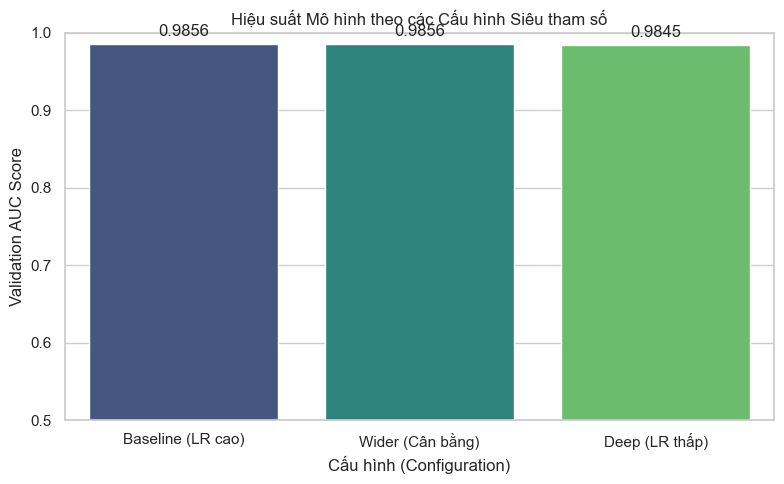

In [6]:
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Config', y='Validation AUC', palette='viridis')
plt.title('Hiệu suất Mô hình theo các Cấu hình Siêu tham số')
plt.ylim(0.5, 1.0) # AUC range
plt.ylabel('Validation AUC Score')
plt.xlabel('Cấu hình (Configuration)')

for index, value in enumerate(results_df['Validation AUC']):
    plt.text(index, value + 0.01, f'{value:.4f}', ha='center')
    
plt.tight_layout()
plt.show()